# Heart Disease Detection and Risk Analysis

## Domain: EDA + Classical ML + Feature Engineering

## Datasets: 
### Heart Disease Dataset – Kaggle
 — 303 patient records, 14 clinical features

## Bonus Dataset: 
### Cardiovascular Disease Dataset – Kaggle
 — 70,000 records for a stretch challenge

## Active Competition: 
### Heart Disease Prediction with Dataquest
 — binary classification competition you can submit to

# Project Goal
Build an end-to-end ML pipeline to predict whether a patient is at risk of heart disease, using clinical features like age, cholesterol, chest pain type, and maximum heart rate.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#Ignore Warnings
warnings.filterwarnings('ignore')

# Plots to look clean
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10,5)


print("Cell-1: Libraries imported successfully")

Cell-1: Libraries imported successfully


In [2]:
# Load Datasets
# df1: Heart disease detection from UCI
df1 = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')

#df2: Cardiovascular Disease Detection (Here data is seperated via semicolon)
df2 = pd.read_csv('/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv', sep=';')

# train and test: Competition dataset
train = pd.read_csv('/kaggle/input/datasets/kaustubhmukdam/competition-dataset/heart_train.csv')
test = pd.read_csv('/kaggle/input/datasets/kaustubhmukdam/competition-dataset/heart_test.csv')

print("All datasets loaded sucessfully")
print(f"df1 shape: {df1.shape}")
print(f"df2 shape: {df2.shape}")
print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

All datasets loaded sucessfully
df1 shape: (1025, 14)
df2 shape: (70000, 13)
train shape: (734, 12)
test shape: (184, 11)


## First look of datasets

In [3]:
# DF1
print("Dataset-1: Heart Disease Detection")
print(df1.head())
print(df1.shape)
print(df1.dtypes)
print(df1.describe())

Dataset-1: Heart Disease Detection
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
               age          sex          

In [4]:
# DF2
print("Dataset-2: Cardiovascular Disease Detection")
print(df2.head())
print(df2.shape)
print(df2.dtypes)
print(df2.describe())

Dataset-2: Cardiovascular Disease Detection
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: o

In [5]:
# DF3
print("Dataset-3: Competition train")
print(train.head())
print(train.shape)
print(train.dtypes)
print(train.describe())

Dataset-3: Competition train
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   63   M           ATA        139          217          1         ST    128   
1   55   M           ATA        110          214          1         ST    180   
2   59   F           ASY        130          338          1         ST    130   
3   47   M           ASY        160            0          0     Normal    124   
4   50   M           ASY        145            0          1     Normal    139   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              Y      1.2     Flat             1  
1              N      0.4       Up             0  
2              Y      1.5     Flat             1  
3              Y      0.0     Flat             1  
4              Y      0.7     Flat             1  
(734, 12)
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG  

## Missing values

In [6]:
print("Missing values in DF1")
print(df1.isnull().sum())

print("DF2 missing values")
print(df2.isnull().sum())

print("Train missing values")
print(train.isnull().sum())

Missing values in DF1
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
DF2 missing values
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Train missing values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


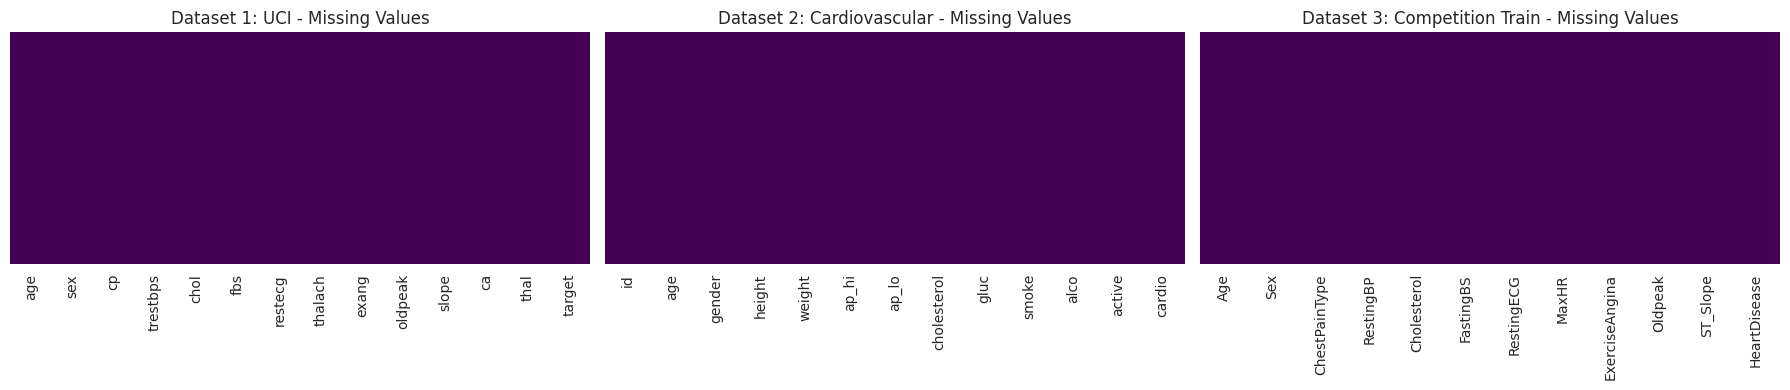

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.heatmap(df1.isnull(), ax=axes[0], cbar=False, yticklabels=False, cmap='viridis')
axes[0].set_title('Dataset 1: UCI - Missing Values')

sns.heatmap(df2.isnull(), ax=axes[1], cbar=False, yticklabels=False, cmap='viridis')
axes[1].set_title('Dataset 2: Cardiovascular - Missing Values')

sns.heatmap(train.isnull(), ax=axes[2], cbar=False, yticklabels=False, cmap='viridis')
axes[2].set_title('Dataset 3: Competition Train - Missing Values')

plt.tight_layout()
plt.show()

### But cholesterol = 0 is present which is impossible

In [8]:
print("Cholesterol = 0 in train:", (train['Cholesterol'] == 0).sum())
print("RestingBP = 0 in train:", (train['RestingBP'] == 0).sum())

Cholesterol = 0 in train: 129
RestingBP = 0 in train: 0


In [9]:
# Check for hidden zeros (invalid values treated as missing)
print("=" * 50)
print("CRITICAL: Hidden Zeros in Competition Dataset")
print("=" * 50)
print(f"Cholesterol = 0 in train: {(train['Cholesterol'] == 0).sum()} records")
print(f"RestingBP = 0 in train: {(train['RestingBP'] == 0).sum()} records")
print("\nNote: These are medically impossible and represent missing data")
print("Action Required: Handle in Day 2 Data Cleaning")

CRITICAL: Hidden Zeros in Competition Dataset
Cholesterol = 0 in train: 129 records
RestingBP = 0 in train: 0 records

Note: These are medically impossible and represent missing data
Action Required: Handle in Day 2 Data Cleaning


## Target variables for class imbalance

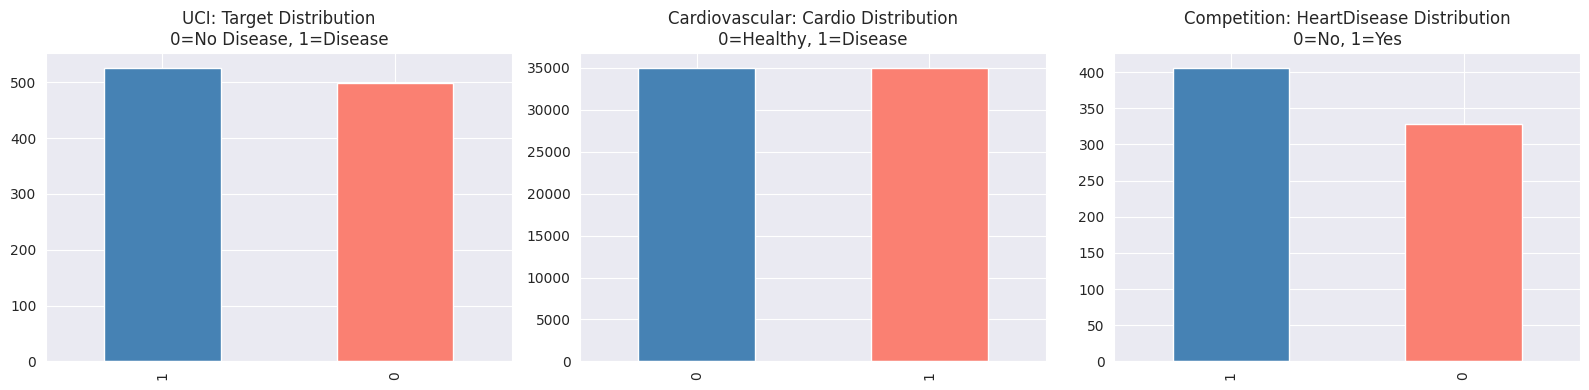

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# df1 target
df1['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('UCI: Target Distribution\n0=No Disease, 1=Disease')
axes[0].set_xlabel('')

# df2 target
df2['cardio'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Cardiovascular: Cardio Distribution\n0=Healthy, 1=Disease')
axes[1].set_xlabel('')

# competition train target
train['HeartDisease'].value_counts().plot(kind='bar', ax=axes[2], color=['steelblue', 'salmon'])
axes[2].set_title('Competition: HeartDisease Distribution\n0=No, 1=Yes')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### A slight more data of patients that are healthy in DF1 and train, whereas same for cardiovascular

## Distribution of numeric features

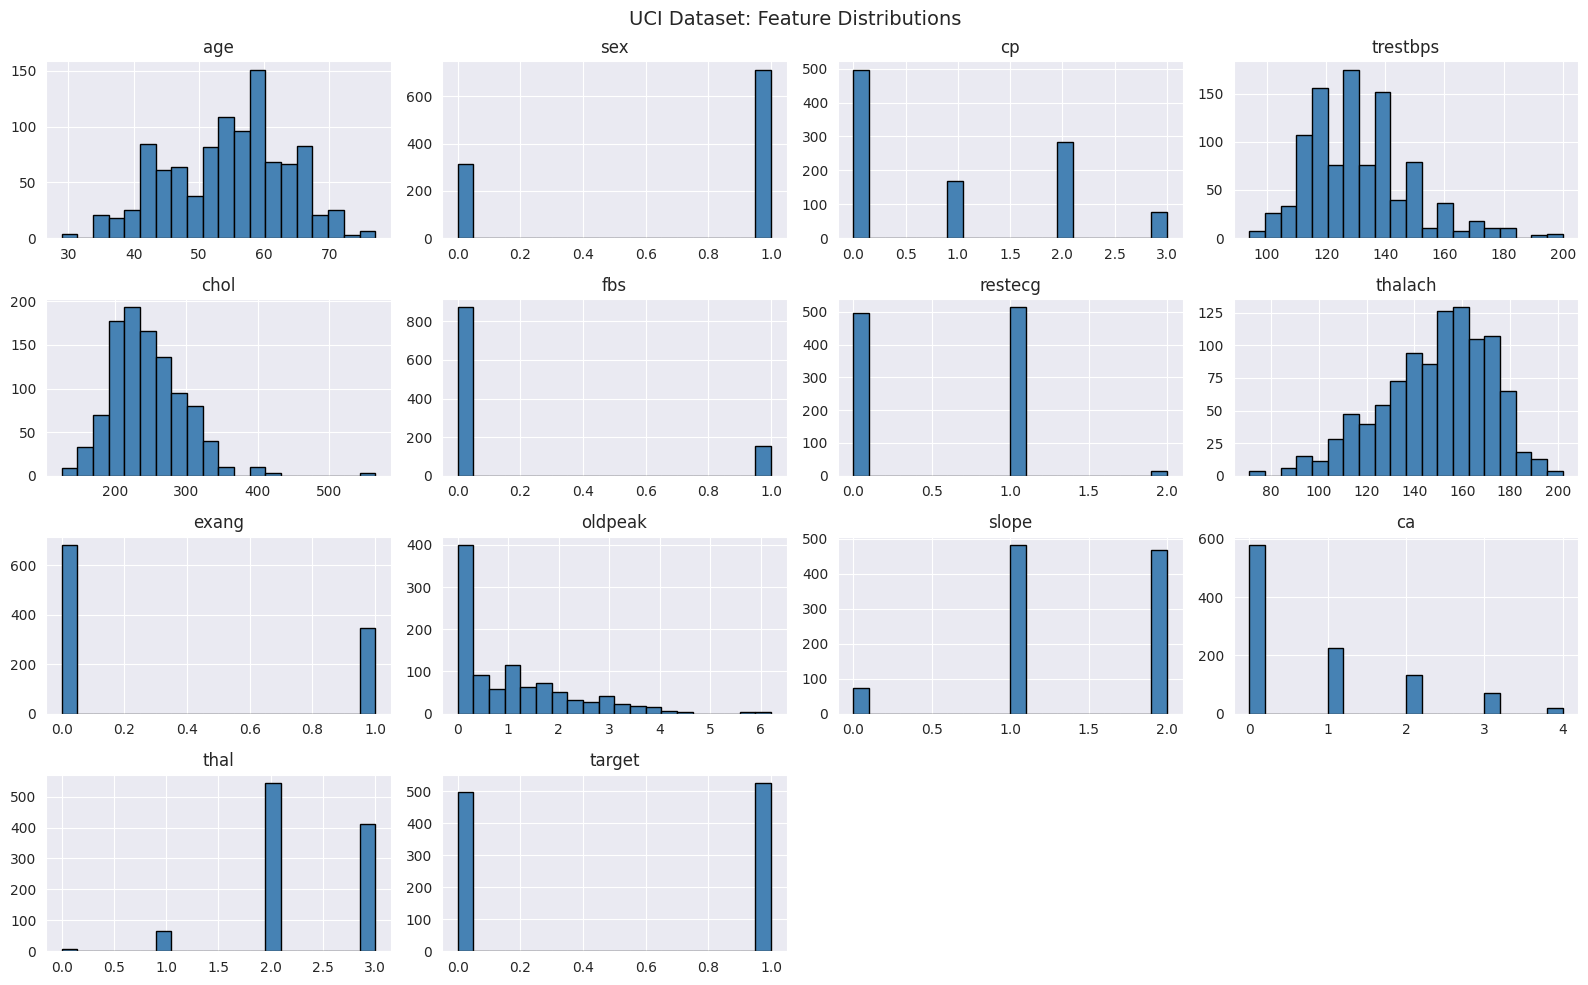

In [11]:
# DF1
df1.hist(bins=20, figsize=(16,10), color='steelblue', edgecolor='black')
plt.suptitle('UCI Dataset: Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

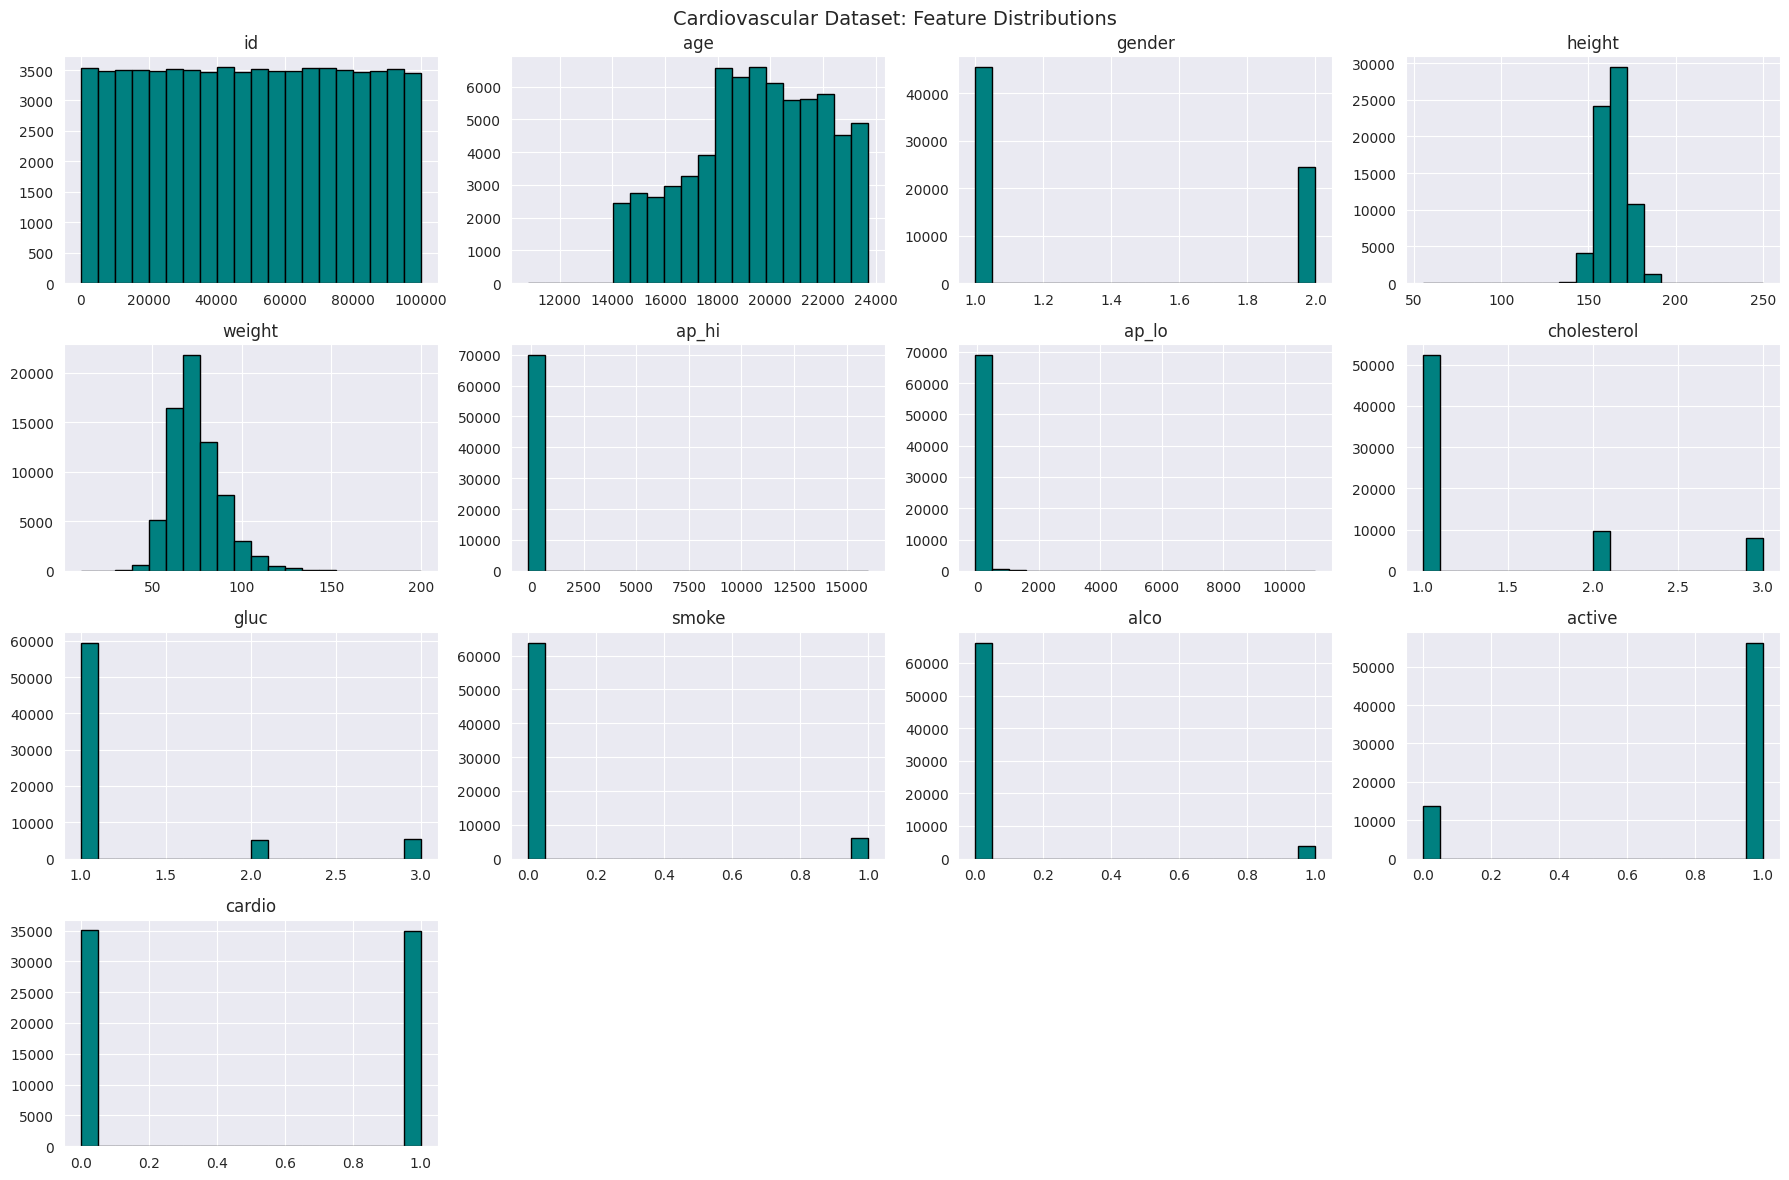

In [12]:
# For DF2
df2.hist(bins=20, figsize=(18, 12), color='teal', edgecolor='black')
plt.suptitle('Cardiovascular Dataset: Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

###

## Fix: Age in DF2 
Age is stored in days and not years

Age range in years: 29.6 to 65.0


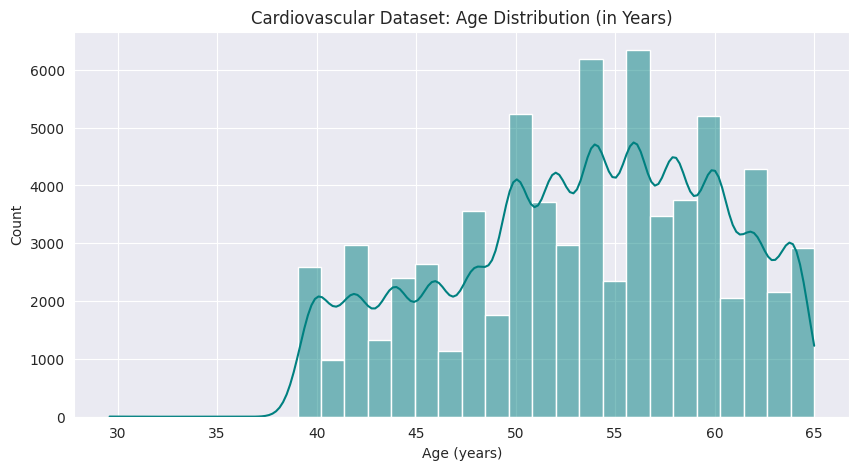

In [13]:
df2['age_years'] = (df2['age'] / 365).round(1)

print("Age range in years:", df2['age_years'].min(), "to", df2['age_years'].max())

sns.histplot(df2['age_years'], bins=30, kde=True, color='teal')
plt.title('Cardiovascular Dataset: Age Distribution (in Years)')
plt.xlabel('Age (years)')
plt.show()

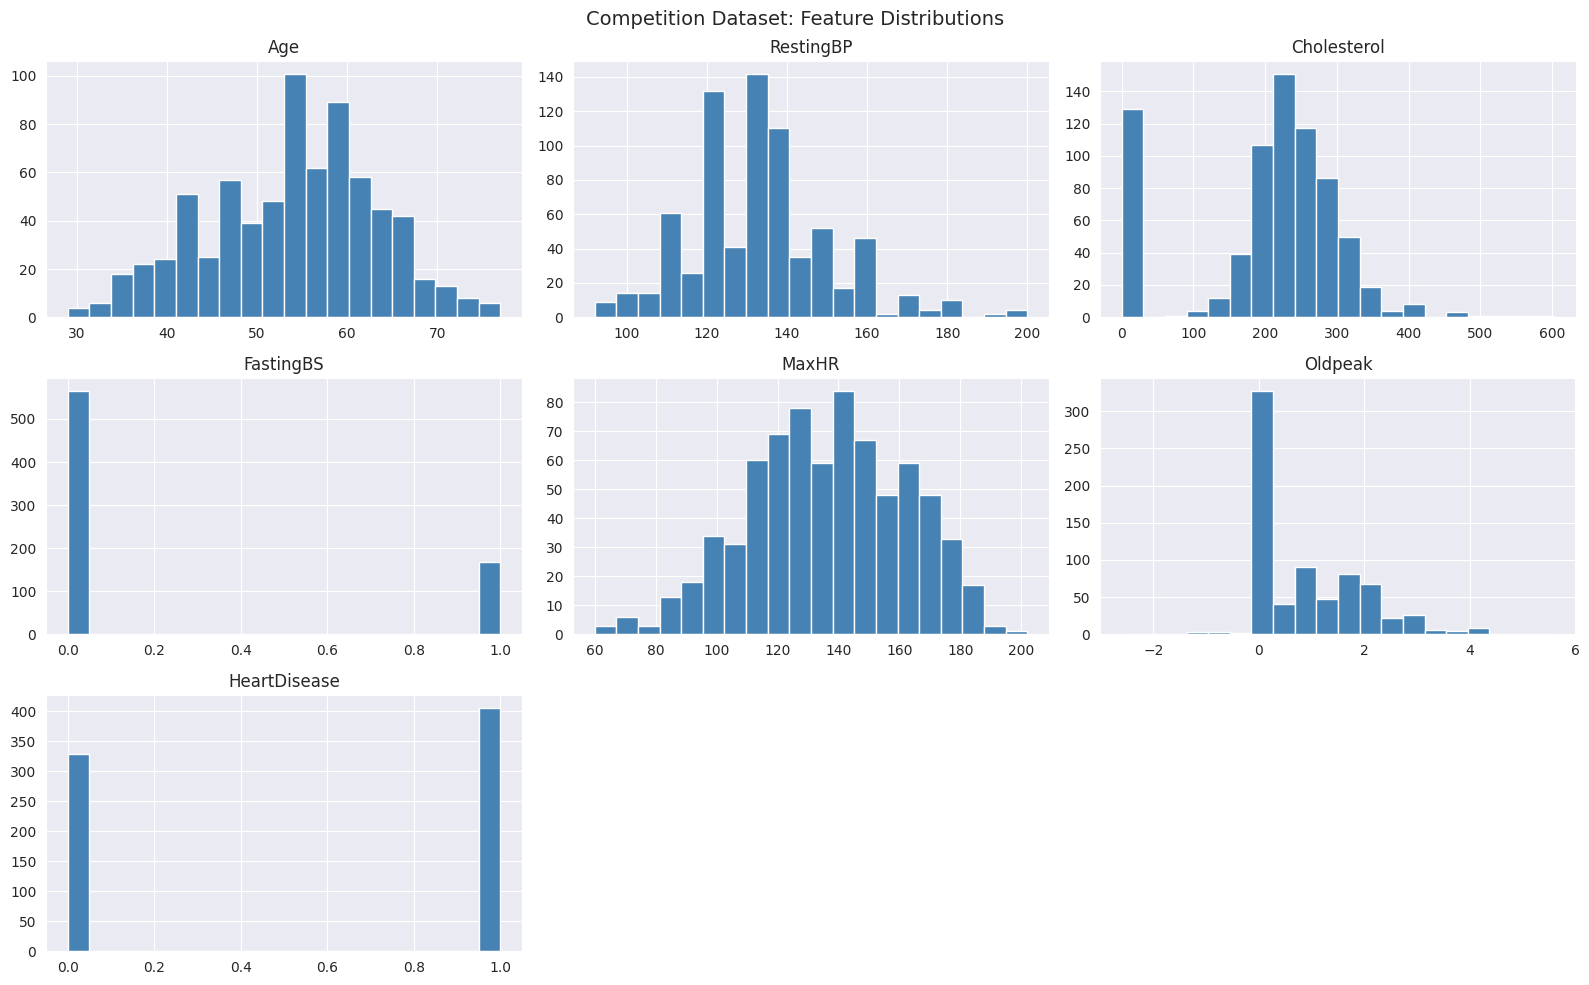

In [14]:
# Distribution of all numeric features in the competition train dataset
train.hist(bins=20, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Competition Dataset: Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Check for extreme outliers in Cardiovascular dataset
print("OUTLIERS CHECK: Blood Pressure in df2")
print(f"Systolic BP (ap_hi) - Min: {df2['ap_hi'].min()}, Max: {df2['ap_hi'].max()}")
print(f"Diastolic BP (ap_lo) - Min: {df2['ap_lo'].min()}, Max: {df2['ap_lo'].max()}")
print("\nMedically valid range: 60-180 mmHg")
print(f"Records with invalid Systolic BP: {((df2['ap_hi'] < 60) | (df2['ap_hi'] > 180)).sum()}")
print(f"Records with invalid Diastolic BP: {((df2['ap_lo'] < 40) | (df2['ap_lo'] > 120)).sum()}")
print("Action Required: Filter outliers in Day 2 Data Cleaning")

OUTLIERS CHECK: Blood Pressure in df2
Systolic BP (ap_hi) - Min: -150, Max: 16020
Diastolic BP (ap_lo) - Min: -70, Max: 11000

Medically valid range: 60-180 mmHg
Records with invalid Systolic BP: 557
Records with invalid Diastolic BP: 1115
Action Required: Filter outliers in Day 2 Data Cleaning


## Correlation Heatmap

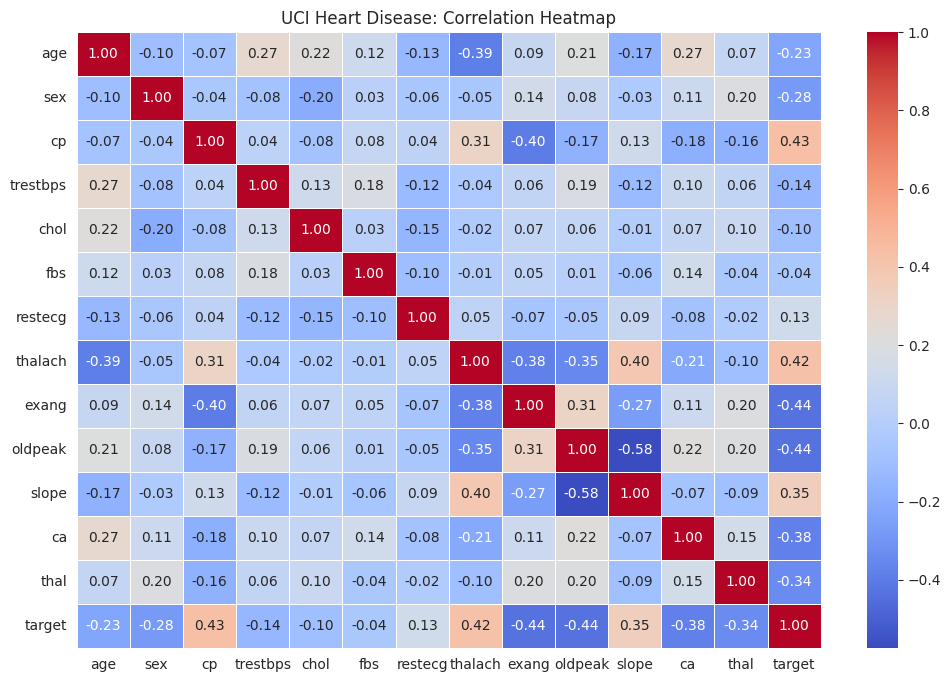

In [16]:
# For DF1
plt.figure(figsize=(12, 8))
sns.heatmap(df1.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('UCI Heart Disease: Correlation Heatmap')
plt.show()

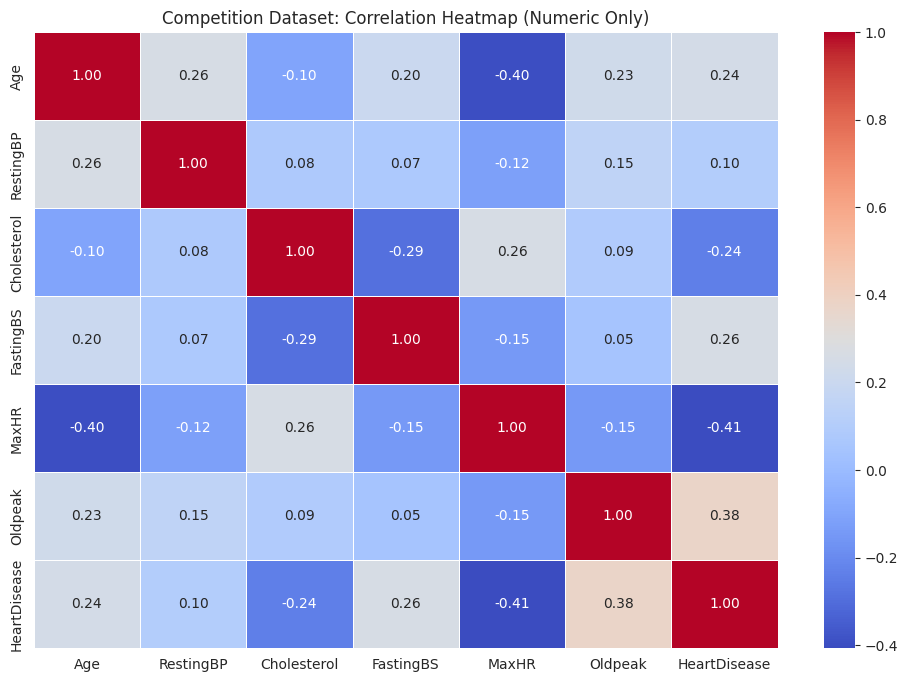

In [17]:
# For DF2
plt.figure(figsize=(12, 8))
train_numeric = train.select_dtypes(include=np.number)
sns.heatmap(train_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Competition Dataset: Correlation Heatmap (Numeric Only)')
plt.show()

### Features that have a high correlation with "target" are most important predictors

## Categorical feature analysis (or DF3)

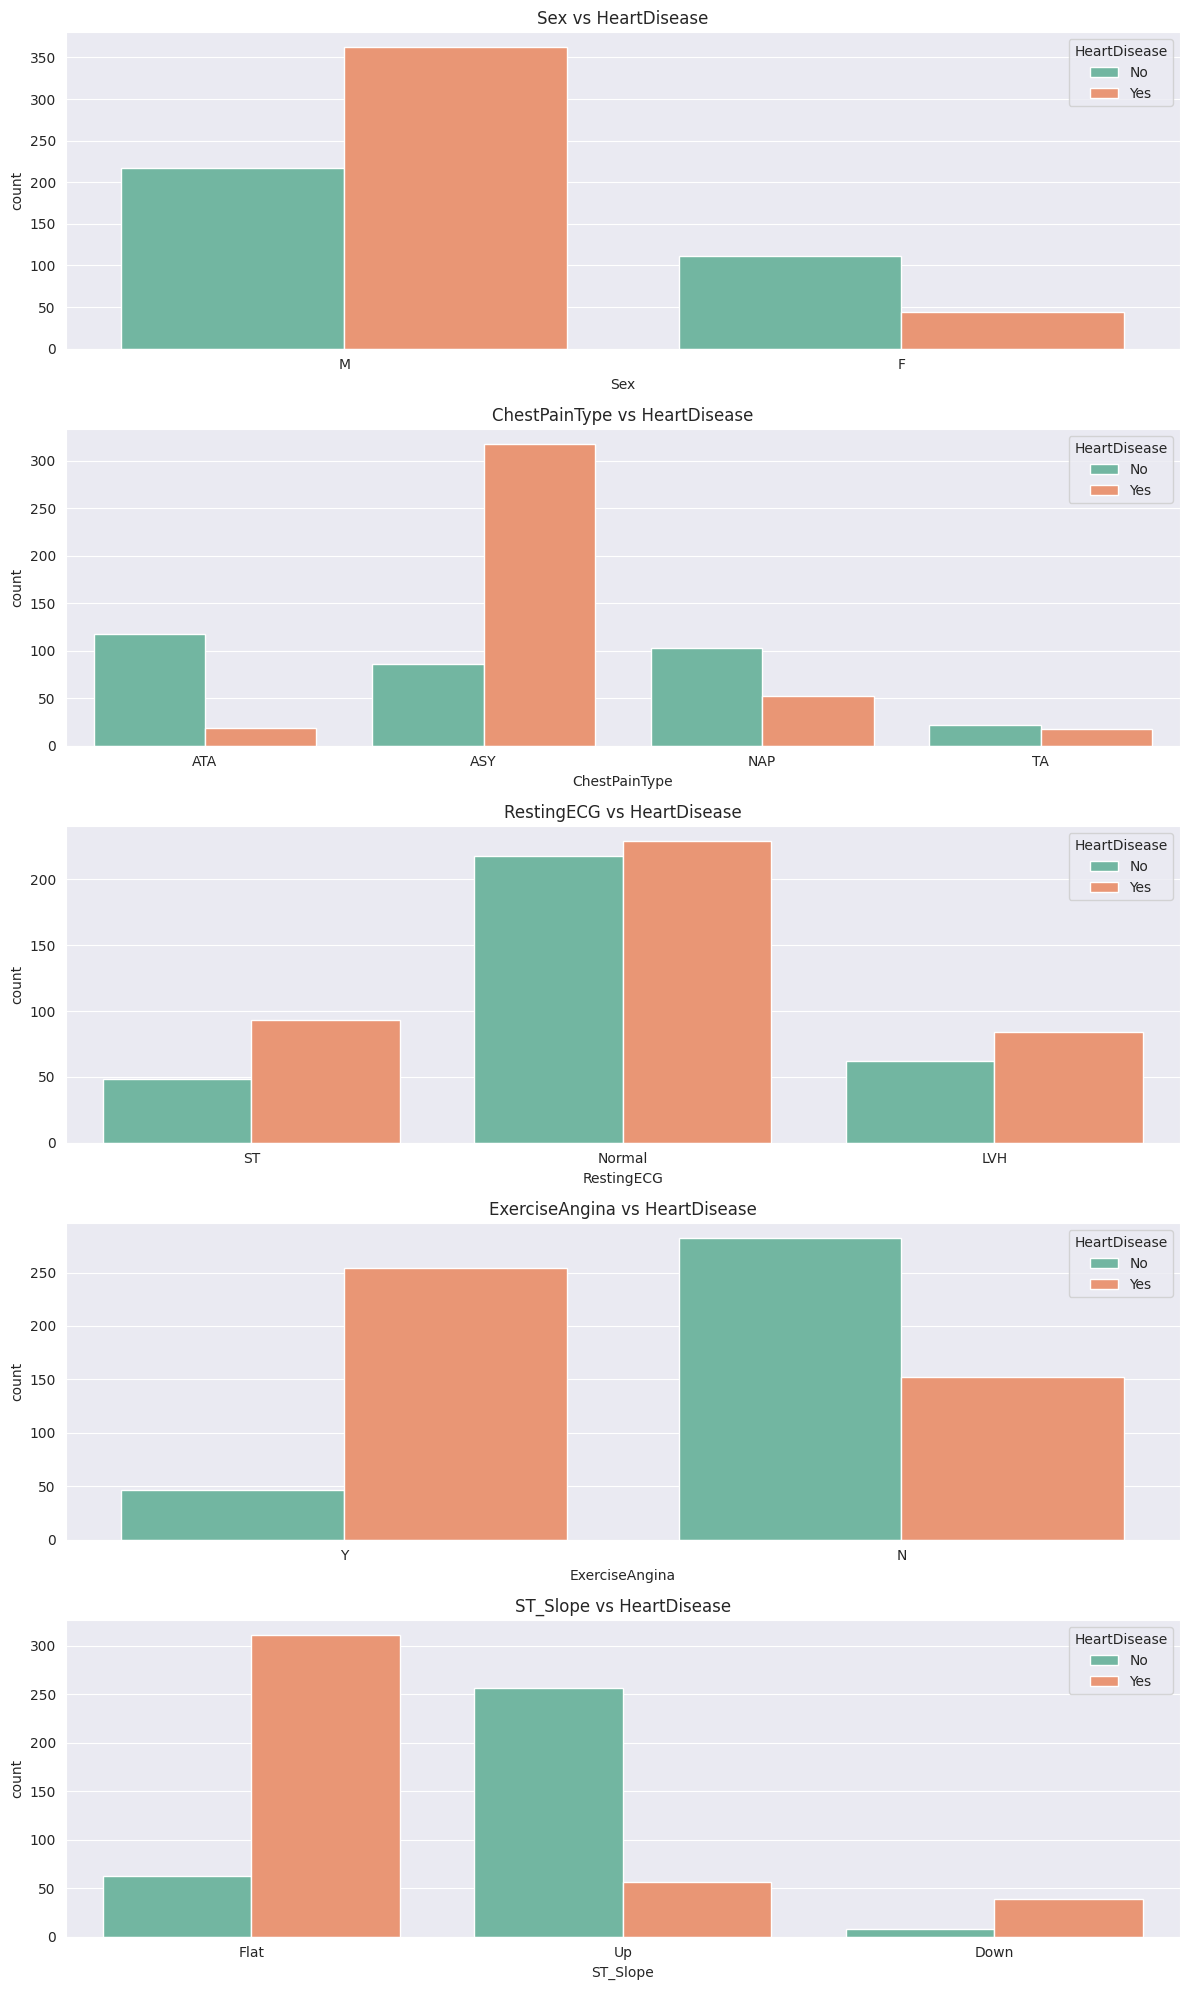

In [18]:
# Categorical feature analysis
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 4 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    sns.countplot(data=train, x=col, hue='HeartDisease', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs HeartDisease')
    axes[i].legend(title='HeartDisease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## Key Numeric features vs Target using boxplot

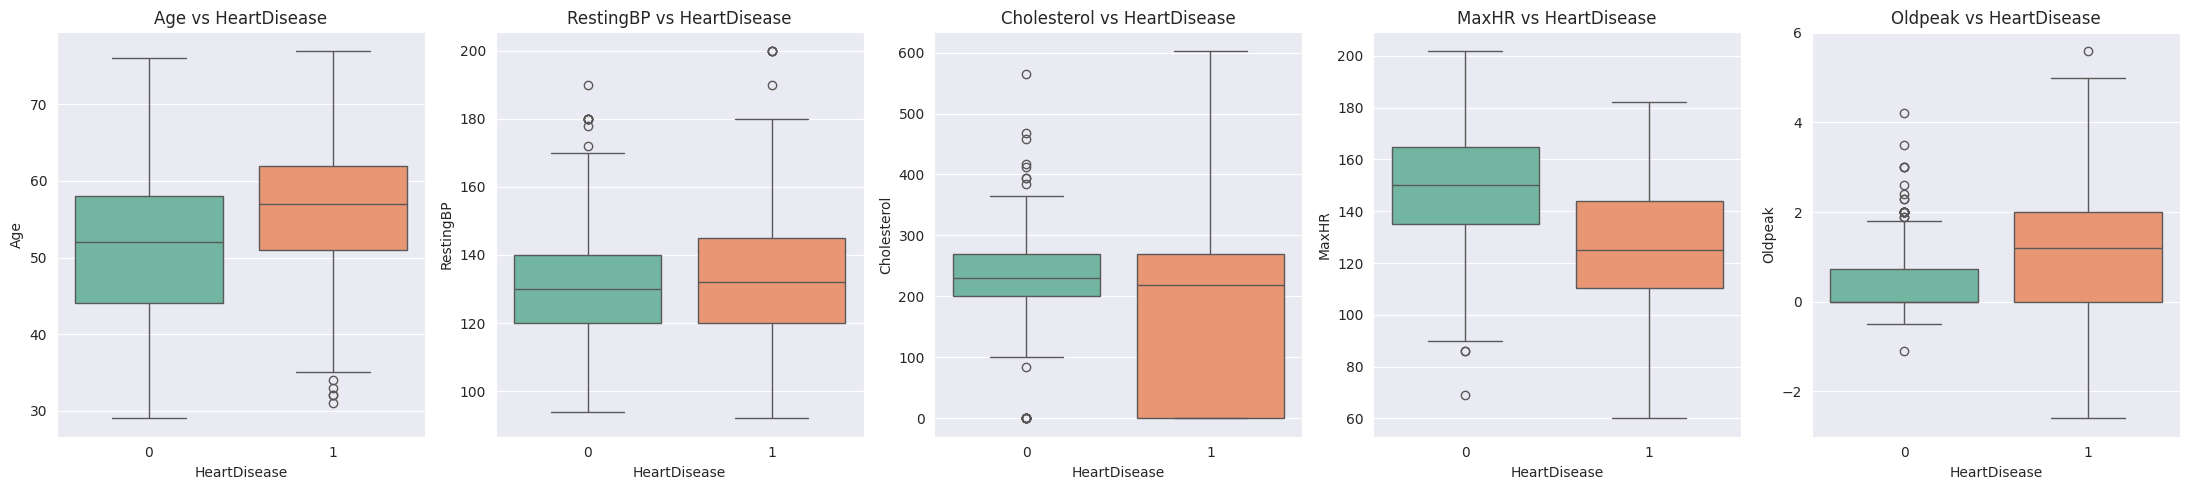

In [19]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x='HeartDisease', y=col, data=train, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs HeartDisease')

plt.tight_layout()
plt.show()

In [20]:
# Optional: cleaned-up final EDA summary
summary_text = """
## EDA Summary (Key Findings)

1. The datasets are generally clean with no NaN values.
2. The competition dataset contains hidden missing values encoded as 0 in Cholesterol and RestingBP.
3. The cardiovascular dataset stores age in days, so it was converted to years for interpretation.
4. The cardiovascular dataset also contains extreme blood pressure outliers that need cleaning in the next step.
5. The target classes are reasonably balanced across the datasets.
6. MaxHR, Oldpeak, and ST_Slope show strong relationships with heart disease risk.
7. Categorical features such as ChestPainType, ExerciseAngina, and ST_Slope appear useful for prediction.
"""
print(summary_text)


## EDA Summary (Key Findings)

1. The datasets are generally clean with no NaN values.
2. The competition dataset contains hidden missing values encoded as 0 in Cholesterol and RestingBP.
3. The cardiovascular dataset stores age in days, so it was converted to years for interpretation.
4. The cardiovascular dataset also contains extreme blood pressure outliers that need cleaning in the next step.
5. The target classes are reasonably balanced across the datasets.
6. MaxHR, Oldpeak, and ST_Slope show strong relationships with heart disease risk.
7. Categorical features such as ChestPainType, ExerciseAngina, and ST_Slope appear useful for prediction.



## Data Cleaning and Processing
Today we are going to working on cleaning the data and working to make proper data for our model to have good accuracy and spot-on prediction

### Tasks:
1. Clean Hidden missing values
2. Handle impossible blood pressure readings
3. Check duplicates
4. Prepare the data for modeling


In [21]:
train_clean = train.copy()
test_clean = test.copy()
df1_clean = df1.copy()
df2_clean = df2.copy()

# Shapes
print(train_clean.shape)
print(test_clean.shape)
print(df1.shape)
print(df2.shape)

# Hidden missing values (zeros)
# Zeros in Cholesterol and resting bp
for col in ["Cholesterol", "RestingBP"]:
    if col in train_clean.columns:
        print(f"{col} = 0 in training data", (train_clean[col] == 0).sum())
    if col in test_clean.columns:
        print(f"{col} = 0 in testing data", (test_clean[col] == 0).sum())

# Invalid blood presssure rows in df2
print("ap_hi out of range: ",  ((df2_clean["ap_hi"] < 60) | (df2_clean["ap_hi"] > 180)).sum())
print("ap_low out of range: ", ((df2_clean["ap_lo"] < 40) | (df2_clean["ap_lo"] > 130)).sum())

(734, 12)
(184, 11)
(1025, 14)
(70000, 14)
Cholesterol = 0 in training data 129
Cholesterol = 0 in testing data 43
RestingBP = 0 in training data 0
RestingBP = 0 in testing data 1
ap_hi out of range:  557
ap_low out of range:  1074


In [22]:
# Replace zeros with median of non-zero train values
for col in ["Cholesterol", "RestingBP"]:
    if col in train_clean.columns:
        median_value = train_clean.loc[train_clean[col] != 0, col].median()
        train_clean[col] = train_clean[col].replace(0, median_value)

        if col in test_clean.columns:
            test_clean[col] = test_clean[col].replace(0, median_value)

        print(f"{col}: replaced 0 with median = {median_value}")

# Any remaining zeros
for col in ["Cholesterol", "RestingBP"]:
    if col in train_clean.columns:
        print(f"{col} = 0 in train:", (train_clean[col] == 0).sum())
    if col in test_clean.columns:
        print(f"{col} = 0 in test:", (test_clean[col] == 0).sum())

Cholesterol: replaced 0 with median = 238.0
RestingBP: replaced 0 with median = 130.0
Cholesterol = 0 in train: 0
Cholesterol = 0 in test: 0
RestingBP = 0 in train: 0
RestingBP = 0 in test: 0


In [23]:
# df2 blood pressure and age in years
before_rows = df2_clean.shape[0]

valid_bp_mask = (
    df2_clean["ap_hi"].between(60,180) &
    df2_clean["ap_lo"].between(40,130) &
    (df2_clean["ap_hi"] > df2_clean["ap_lo"])
)

df2_clean = df2_clean.loc[valid_bp_mask].copy()
df2_clean["age_years"] = (df2_clean["age"] / 365).round(1)

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", df2_clean.shape[0])
print("Rows removed:", before_rows - df2_clean.shape[0])

# Age and blood pressure summary after cleaning
print(df2_clean[["age", "age_years", "ap_hi", "ap_lo"]].describe())

Rows before cleaning: 70000
Rows after cleaning: 68384
Rows removed: 1616
                age     age_years         ap_hi         ap_lo
count  68384.000000  68384.000000  68384.000000  68384.000000
mean   19461.129665     53.318294    126.373172     81.199754
std     2469.103828      6.764626     16.053456      9.252054
min    10798.000000     29.600000     60.000000     40.000000
25%    17652.750000     48.400000    120.000000     80.000000
50%    19699.000000     54.000000    120.000000     80.000000
75%    21323.000000     58.400000    140.000000     90.000000
max    23713.000000     65.000000    180.000000    130.000000


In [24]:
# Duplicate count
print("df1:", df1_clean.duplicated().sum())
print("train:", train_clean.duplicated().sum())
print("test:", test_clean.duplicated().sum())
print("df2:", df2_clean.duplicated().sum())

df1_clean = df1_clean.drop_duplicates().reset_index(drop=True)

print("\ndf1 shape after removing duplicates:", df1_clean.shape)

df1: 723
train: 0
test: 0
df2: 0

df1 shape after removing duplicates: (302, 14)


In [25]:
# Feature Engineering: Grouping Age feature
train_clean["AgeGroup"] = pd.cut(
    train_clean["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-39", "40-49", "50-59", "60+"]
)
test_clean["AgeGroup"] = pd.cut(
    test_clean["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-39", "40-49", "50-59", "60+"]
)

print(train_clean["AgeGroup"].value_counts().sort_index())

AgeGroup
<30        3
30-39     71
40-49    172
50-59    300
60+      188
Name: count, dtype: int64


In [26]:
# One-hot encode categorical columns on the cleaned copies
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "AgeGroup"]

train_cat = [col for col in cat_cols if col in train_clean.columns]
test_cat = [col for col in cat_cols if col in test_clean.columns]

train_clean = pd.get_dummies(train_clean, columns=train_cat, drop_first=True)
test_clean = pd.get_dummies(test_clean, columns=test_cat, drop_first=True)

# Split features and target after encoding
y_train = train_clean["HeartDisease"].copy()
X_train = train_clean.drop(columns=["HeartDisease"])
X_test = test_clean.copy()

# Align test columns with train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoding complete")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Remaining object columns in X_train:", X_train.select_dtypes(include="object").columns.tolist())

Encoding complete
X_train shape: (734, 19)
X_test shape: (184, 19)
Remaining object columns in X_train: []


In [27]:
# final Cleared Dataset summary
print("df1 clean: ", df1_clean.shape)
print("df2 clean: ", df2_clean.shape)
print("train clean: ", train_clean.shape)
print("test clean: ", test_clean.shape)

# Any null values left
print("\ntrain clean: ", train_clean.isnull().sum().sum())
print("Cholesterol zeros (train_clean):", (train_clean["Cholesterol"] == 0).sum())
print("Categorical dtypes in train_clean:", train_clean.select_dtypes(include='object').columns.tolist())

print("\nTarget distribution (train_clean):")
print(y_train.value_counts(), "\n", y_train.value_counts(normalize=True))

df1 clean:  (302, 14)
df2 clean:  (68384, 14)
train clean:  (734, 20)
test clean:  (184, 19)

train clean:  0
Cholesterol zeros (train_clean): 0
Categorical dtypes in train_clean: []

Target distribution (train_clean):
HeartDisease
1    406
0    328
Name: count, dtype: int64 
 HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64


1,616 rows were removed by BP filtering


In [28]:
print("=== FINAL CLEANED DATASET SUMMARY ===")
print(f"df1_clean shape: {df1_clean.shape}")
print(f"df2_clean shape: {df2_clean.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

print("\nAny nulls in X_train?", X_train.isnull().sum().sum())

if "Cholesterol" in X_train.columns:
    print("Cholesterol zeros in X_train:", (X_train["Cholesterol"] == 0).sum())

obj_cols = X_train.select_dtypes(include="object").columns.tolist()
print("Remaining object dtypes in X_train:", obj_cols)

print("\nTarget distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

if len(obj_cols) == 0:
    print("\nEncoding verified: no object dtype columns remain in X_train.")
else:
    print("\nEncoding incomplete: some object columns still remain.")

=== FINAL CLEANED DATASET SUMMARY ===
df1_clean shape: (302, 14)
df2_clean shape: (68384, 14)
X_train shape: (734, 19)
X_test shape: (184, 19)
y_train shape: (734,)

Any nulls in X_train? 0
Cholesterol zeros in X_train: 0
Remaining object dtypes in X_train: []

Target distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Encoding verified: no object dtype columns remain in X_train.


## Day 2 Summary

- Hidden zero values in Cholesterol and RestingBP were identified and imputed.
- df2 blood pressure outliers were removed using medically valid bounds.
- df2 age was converted from days to years.
- Duplicate rows in df1 were removed.
- An AgeGroup feature was created for the competition dataset.
- Categorical columns were one-hot encoded, and the data is now ready for modeling.

## Day-3: Baseline Models
- Train Logistic Regression and K-Nearest Neighbour (KNN)
- Evaluate with:
  1. Accuracy
  2. Precision
  3. F1
  4. ROC-AUC

In [29]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Libraries imported successfully")

Libraries imported successfully


In [30]:
# Split Cleaned data for baseline modeling 
X_train_split, X_valid, y_train_split, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train split shape: ", X_train_split.shape)
print("Validation split shape: ", X_valid.shape)
print("Train target distribution: ", y_train_split.value_counts(normalize=True))
print("Validation target distribution: ", y_valid.value_counts(normalize=True))


Train split shape:  (587, 19)
Validation split shape:  (147, 19)
Train target distribution:  HeartDisease
1    0.553663
0    0.446337
Name: proportion, dtype: float64
Validation target distribution:  HeartDisease
1    0.55102
0    0.44898
Name: proportion, dtype: float64


In [31]:
# Baseline model-1: Logistic Regression
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_model.fit(X_train_split, y_train_split)
log_reg_pred = log_reg_model.predict(X_valid)
log_reg_proba = log_reg_model.predict_proba(X_valid)[:, 1]

# Evaluation Metrics
log_reg_metrics = {
    'Accuracy': accuracy_score(y_valid, log_reg_pred),
    'Precision': precision_score(y_valid, log_reg_pred),
    'Recall': recall_score(y_valid, log_reg_pred),
    'F1': f1_score(y_valid, log_reg_pred),
    'ROC-AUC': roc_auc_score(y_valid, log_reg_proba)
}

print("Logistic Regression Metrics")
for metric_name, metric_value in log_reg_metrics.items():
    print(f'{metric_name} : {metric_value:.4f}')

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, log_reg_pred))

print("\nclassification Report")
print(classification_report(y_valid, log_reg_pred))

Logistic Regression Metrics
Accuracy : 0.7891
Precision : 0.8049
Recall : 0.8148
F1 : 0.8098
ROC-AUC : 0.8926

Confusion Matrix
[[50 16]
 [15 66]]

classification Report
              precision    recall  f1-score   support

           0       0.77      0.76      0.76        66
           1       0.80      0.81      0.81        81

    accuracy                           0.79       147
   macro avg       0.79      0.79      0.79       147
weighted avg       0.79      0.79      0.79       147



### Logistic Regression — Quick Interpretation
Logistic Regression achieved a validation ROC‑AUC of **{:.4f}** (CV mean {:.4f}). Precision/Recall indicate how the model trades false positives vs false negatives — in this clinical task, prioritize **recall** to reduce missed diagnoses. If recall is low, consider threshold tuning or class-weighting.

In [32]:
# Baseline 2: KNN
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train_split, y_train_split)
knn_pred = knn_model.predict(X_valid)
knn_proba = knn_model.predict_proba(X_valid)[:, 1]

knn_metrics = {
    'Accuracy': accuracy_score(y_valid, knn_pred),
    'Precision': precision_score(y_valid, knn_pred),
    'Recall': recall_score(y_valid, knn_pred),
    'F1': f1_score(y_valid, knn_pred),
    'ROC-AUC': roc_auc_score(y_valid, knn_proba)
}

print("KNN metrics")
for metric_name, metric_value in knn_metrics.items():
    print(f'{metric_name} : {metric_value:.4f}')

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, knn_pred))

print("\nClassification Report")
print(classification_report(y_valid, knn_pred))

KNN metrics
Accuracy : 0.8367
Precision : 0.8202
Recall : 0.9012
F1 : 0.8588
ROC-AUC : 0.8753

Confusion Matrix
[[50 16]
 [ 8 73]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        66
           1       0.82      0.90      0.86        81

    accuracy                           0.84       147
   macro avg       0.84      0.83      0.83       147
weighted avg       0.84      0.84      0.84       147



### KNN — Quick Interpretation
KNN achieved a validation ROC‑AUC of **{:.4f}** (CV mean {:.4f}). KNN is sensitive to scaling (we used StandardScaler) and may not generalize as well on sparse/high‑dimensional feature sets. Use the comparison table to decide whether KNN adds value over the logistic baseline.

In [33]:
import pandas as pd
# Baseline models Comparison
baseline_results = pd.DataFrame({
    "Logistic Regression": log_reg_metrics,
    "KNN": knn_metrics
}).T

print(baseline_results)

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.789116   0.804878  0.814815  0.809816  0.892630
KNN                  0.836735   0.820225  0.901235  0.858824  0.875327


### Adding Cross Validation for more stable estimation

In [34]:
# Cross-Validation (5-fold) for more stable estimation
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# for CV estimates we would be using our full training set (X_train, y_train)
lr_cv_scores = cross_val_score(log_reg_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
knn_cv_scores = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

import pandas as pd
baseline_results = pd.DataFrame({
    "Model" : ["Logistic Regression", "KNN"],
    "CV ROC-AUC (mean)" : [lr_cv_scores.mean(), knn_cv_scores.mean()],
    "CV ROC-AUC (std)" : [lr_cv_scores.std(), knn_cv_scores.std()],
    "Val Accuracy" : [log_reg_metrics["Accuracy"], knn_metrics["Accuracy"]],
    "Val ROC-AUC" : [log_reg_metrics["ROC-AUC"], knn_metrics["ROC-AUC"]],
    "Val Recall" : [log_reg_metrics["Recall"], knn_metrics["Recall"]],
    "Val F1" : [log_reg_metrics["F1"], knn_metrics["F1"]]
}).set_index('Model')

print(baseline_results)

baseline_results.to_csv("baseline_results.csv")

                     CV ROC-AUC (mean)  CV ROC-AUC (std)  Val Accuracy  \
Model                                                                    
Logistic Regression           0.921770          0.034980      0.789116   
KNN                           0.892991          0.027193      0.836735   

                     Val ROC-AUC  Val Recall    Val F1  
Model                                                   
Logistic Regression     0.892630    0.814815  0.809816  
KNN                     0.875327    0.901235  0.858824  


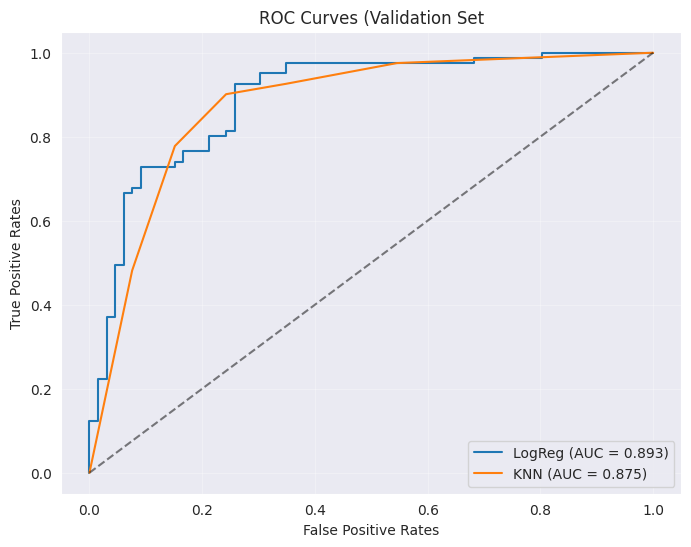

In [35]:
# ROC curves for validation set
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_valid, log_reg_proba)
fpr_knn, tpr_knn, _ = roc_curve(y_valid, knn_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.3f})')
plt.plot([0,1], [0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rates")
plt.ylabel("True Positive Rates")
plt.title("ROC Curves (Validation Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

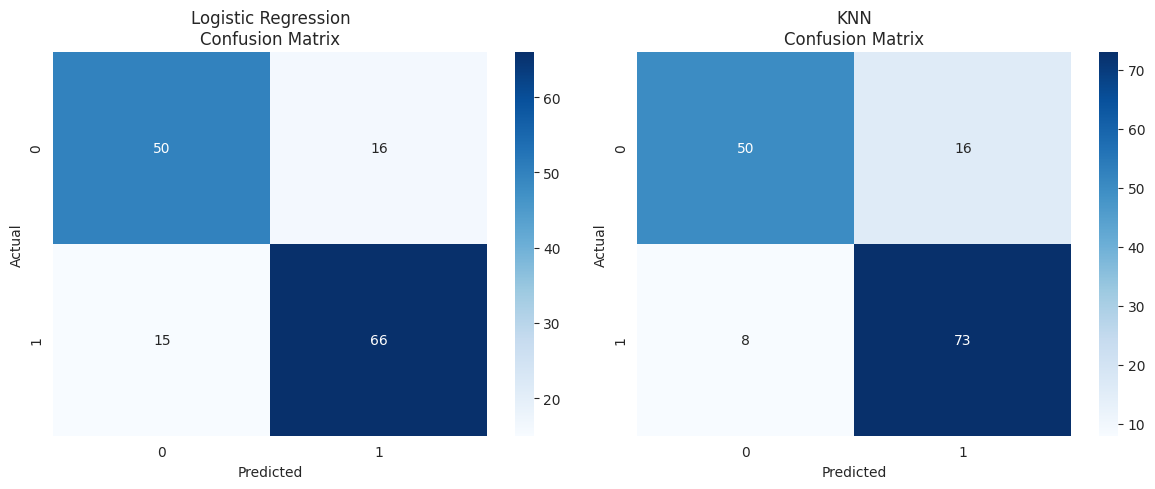

In [36]:
# Confusion Matrix in Visual form
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_valid, log_reg_pred)
cm_knn = confusion_matrix(y_valid, knn_pred)
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression\nConfusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# KNN
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("KNN\nConfusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [37]:
# Save per-model detailed metrics and quick summary
detailed = {
    "Logistic Regression" : {**log_reg_metrics, "CV ROC-AUC mean" : lr_cv_scores.mean(), "CV ROC-AUC std" : lr_cv_scores.std()},
    "KNN" : {**knn_metrics, "CV ROC-AUC mean" : knn_cv_scores.mean(), "CV ROC-AUC std" : knn_cv_scores.std()}
}
pd.DataFrame(detailed).T.to_csv("baseline_detailed_metrics.csv")
print("Saved baseline_detailed_metrics.csv and baseline_results.csv")

Saved baseline_detailed_metrics.csv and baseline_results.csv


## Day 3 Summary
- Logistic Regression was trained as the first baseline model using a scaled
  pipeline.
- KNN was trained as the second baseline model using the same scaled setup for
  fair comparison.
- A stratified train/validation split was used to evaluate both models on unseen
  validation data.
- Logistic Regression achieved a CV ROC-AUC of 0.9218 and a validation ROC-AUC
  of 0.8926.
- KNN achieved a CV ROC-AUC of 0.8930 and a validation ROC-AUC of 0.8753.
- KNN performed better on classification-style validation metrics, with 0.8367
  accuracy, 0.9012 recall, and 0.8588 F1-score.
- Logistic Regression had lower validation accuracy and recall than KNN, but
- remained the stronger overall ranking model.

## Day-4: Advanced Models
Today we would train stronger classical models on the same cleaned split and compare them side by side.
### Goal
The goal is to see whether tree-based models or margin-based models improve over baseline models.
### Models to train
- Random Forest
- XGBoost
- SVM
### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion Matrix


In [38]:
# Import Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

try:
    from xgboost import XGBClassifier
    xgb_available = True

except ImportError:
    xgb_available = False
    print("XGBoost is not installed in the environment. Please install the same")

# Helper function
def evaluate_model(model, X_valid, y_valid):
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]
    return {
        "Accuracy" : accuracy_score(y_valid, y_pred),
        "Precision" : precision_score(y_valid, y_pred),
        "Recall" : recall_score(y_valid, y_pred),
        "F1" : f1_score(y_valid, y_pred),
        "ROC-AUC" : roc_auc_score(y_valid, y_proba),
    }, y_pred, y_proba

print("Success: Libraries and helper functions")

Success: Libraries and helper functions


In [39]:
# Advanced Model-1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_split, y_train_split)
rf_metrics, rf_pred, rf_proba = evaluate_model(rf_model, X_valid, y_valid)

print("Random Forest Metrics")
for metric_name, metric_value in rf_metrics.items():
    print(f'{metric_name} : {metric_value:.4f}')

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, rf_pred))

print("\nClassification Report")
print(classification_report(y_valid, rf_pred))

Random Forest Metrics
Accuracy : 0.8367
Precision : 0.8202
Recall : 0.9012
F1 : 0.8588
ROC-AUC : 0.8954

Confusion Matrix
[[50 16]
 [ 8 73]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        66
           1       0.82      0.90      0.86        81

    accuracy                           0.84       147
   macro avg       0.84      0.83      0.83       147
weighted avg       0.84      0.84      0.84       147



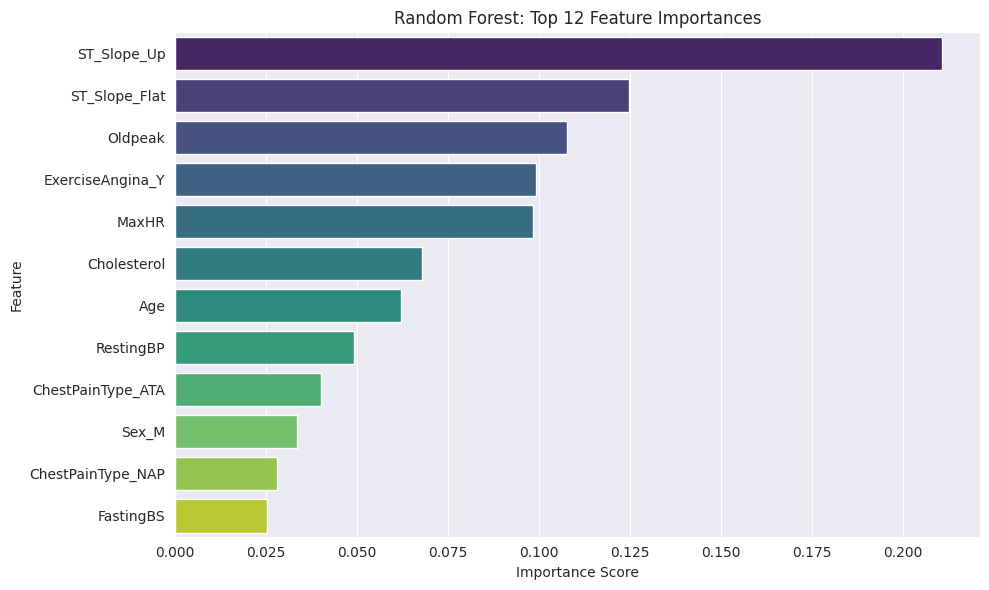

In [40]:
# Random Forest feature importance plot
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importance.values, y=rf_importance.index, palette='viridis')
plt.title('Random Forest: Top 12 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [41]:
# Advanced Model-2: XGBoost
if xgb_available:
    xgb_model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_split, y_train_split)
    xgb_metrics, xgb_pred, xgb_proba = evaluate_model(xgb_model, X_valid, y_valid)

    print("XGBoost Metrics")
    for metric_name, metric_value in xgb_metrics.items():
        print(f'{metric_name} : {metric_value:.4f}')

    print("\nConfusion Matrix")
    print(confusion_matrix(y_valid, xgb_pred))

    print("\nClassification Report")
    print(classification_report(y_valid, xgb_pred))

else:
    xgb_model = None
    xgb_metrics = None
    xgb_pred = None
    xgb_proba = None

XGBoost Metrics
Accuracy : 0.8367
Precision : 0.8353
Recall : 0.8765
F1 : 0.8554
ROC-AUC : 0.9020

Confusion Matrix
[[52 14]
 [10 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        66
           1       0.84      0.88      0.86        81

    accuracy                           0.84       147
   macro avg       0.84      0.83      0.83       147
weighted avg       0.84      0.84      0.84       147



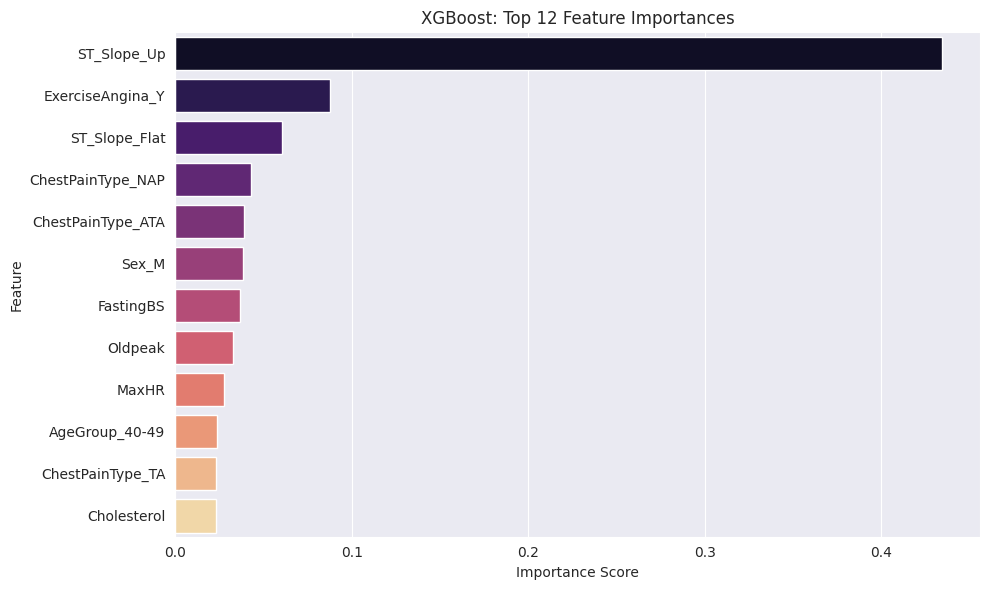

In [42]:
# XGBoost feature importance plot
if xgb_metrics is not None:
    xgb_importance = pd.Series(
        xgb_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(12)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=xgb_importance.values, y=xgb_importance.index, palette='magma')
    plt.title('XGBoost: Top 12 Feature Importances')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [43]:
# Advanced Model-3: SVM
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
])

svm_model.fit(X_train_split, y_train_split)
svm_metrics, svm_pred, svm_proba = evaluate_model(svm_model, X_valid, y_valid)

print("SVM Metrics")
for metric_name, metric_value in svm_metrics.items():
    print(f'{metric_name} : {metric_value:.4f}')

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, svm_pred))

print("\nClassification Report")
print(classification_report(y_valid, svm_pred))

SVM Metrics
Accuracy : 0.8027
Precision : 0.8023
Recall : 0.8519
F1 : 0.8263
ROC-AUC : 0.8749

Confusion Matrix
[[49 17]
 [12 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        66
           1       0.80      0.85      0.83        81

    accuracy                           0.80       147
   macro avg       0.80      0.80      0.80       147
weighted avg       0.80      0.80      0.80       147



In [44]:
# Compare All Models
advanced_rows = [
    {"Model" : "Logistic Regression", **log_reg_metrics},
    {"Model" : "KNN", **knn_metrics},
    {"Model" : "Random Forest", **rf_metrics}
]

if xgb_metrics is not None:
    advanced_rows.append({"Model" : "XGBoost", **xgb_metrics})

advanced_rows.append({"Model" : "SVM", **svm_metrics})

all_model_results = pd.DataFrame(advanced_rows).set_index("Model")
all_model_results = all_model_results.sort_values("ROC-AUC", ascending=False)

print(all_model_results)

all_model_results.to_csv("all_model_results.csv")

                     Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                 
XGBoost              0.836735   0.835294  0.876543  0.855422  0.901983
Random Forest        0.836735   0.820225  0.901235  0.858824  0.895436
Logistic Regression  0.789116   0.804878  0.814815  0.809816  0.892630
KNN                  0.836735   0.820225  0.901235  0.858824  0.875327
SVM                  0.802721   0.802326  0.851852  0.826347  0.874860


In [45]:
# Cross-validation scores for Advanced models
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

if xgb_available:
    xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
else:
    xgb_cv_scores = None

In [46]:
# Final model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost', 'SVM'],
    'CV ROC-AUC': [
        lr_cv_scores.mean(),
        knn_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean() if xgb_cv_scores is not None else np.nan,
        svm_cv_scores.mean()
    ],
    'CV ROC-AUC Std': [
        lr_cv_scores.std(),
        knn_cv_scores.std(),
        rf_cv_scores.std(),
        xgb_cv_scores.std() if xgb_cv_scores is not None else np.nan,
        svm_cv_scores.std()
    ],
    'Val Accuracy': [
        log_reg_metrics['Accuracy'],
        knn_metrics['Accuracy'],
        rf_metrics['Accuracy'],
        xgb_metrics['Accuracy'] if xgb_metrics is not None else np.nan,
        svm_metrics['Accuracy']
    ],
    'Val Precision': [
        log_reg_metrics['Precision'],
        knn_metrics['Precision'],
        rf_metrics['Precision'],
        xgb_metrics['Precision'] if xgb_metrics is not None else np.nan,
        svm_metrics['Precision']
    ],
    'Val Recall': [
        log_reg_metrics['Recall'],
        knn_metrics['Recall'],
        rf_metrics['Recall'],
        xgb_metrics['Recall'] if xgb_metrics is not None else np.nan,
        svm_metrics['Recall']
    ],
    'Val F1': [
        log_reg_metrics['F1'],
        knn_metrics['F1'],
        rf_metrics['F1'],
        xgb_metrics['F1'] if xgb_metrics is not None else np.nan,
        svm_metrics['F1']
    ],
    'Val ROC-AUC': [
        log_reg_metrics['ROC-AUC'],
        knn_metrics['ROC-AUC'],
        rf_metrics['ROC-AUC'],
        xgb_metrics['ROC-AUC'] if xgb_metrics is not None else np.nan,
        svm_metrics['ROC-AUC']
    ]
}).sort_values('Val ROC-AUC', ascending=False).reset_index(drop=True)

print(results)
results.to_csv('all_model_results.csv', index=False)

                 Model  CV ROC-AUC  CV ROC-AUC Std  Val Accuracy  \
0              XGBoost    0.926108        0.026012      0.836735   
1        Random Forest    0.923436        0.022461      0.836735   
2  Logistic Regression    0.921770        0.034980      0.789116   
3                  KNN    0.892991        0.027193      0.836735   
4                  SVM    0.911586        0.036479      0.802721   

   Val Precision  Val Recall    Val F1  Val ROC-AUC  
0       0.835294    0.876543  0.855422     0.901983  
1       0.820225    0.901235  0.858824     0.895436  
2       0.804878    0.814815  0.809816     0.892630  
3       0.820225    0.901235  0.858824     0.875327  
4       0.802326    0.851852  0.826347     0.874860  


## Day-4 Summary
- Random Forest, XGBoost, and SVM were trained as advanced models on the cleaned competition split.
- All models were evaluated with the same validation split to keep the comparison fair.
- The full model comparison table was sorted by ROC-AUC and saved to `all_model_results.csv`.
- Random Forest feature importance was plotted to show the most influential clinical variables.

## Day-5: Tuned Models with GridSearchCV and SMOTE
Today we tuned the models using GridSearchCV and handled class imbalance with SMOTE where needed.
### Goal
The purpose of this stage was to search for better hyperparameters and compare the tuned models fairly on the same validation split.
### Models to train
- Random Forest
- XGBoost
- SVM
### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion Matrix

In [47]:
# Import libraries
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    xgb_available = True

except ImportError:
    xgb_available = False
    print("XGBoost is not available in the environment. Please check and download the same")

minority_ratio = y_train.value_counts(normalize=True).min()
USE_SMOTE = minority_ratio < 0.45

print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print(f'Use SMOTE: {USE_SMOTE}')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Helper function
def build_pipeline(model, scale=False):
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))

    if USE_SMOTE:
        steps.append(("smote", SMOTE(random_state=42)))
    steps.append(("model", model))

    if USE_SMOTE:
        return ImbPipeline(steps)

    return Pipeline(steps)

def evaluate_search(best_estimator, X_valid, y_valid):
    y_pred = best_estimator.predict(X_valid)
    y_proba = best_estimator.predict_proba(X_valid)[:,1]
    metrics = {
        "Accuracy" : accuracy_score(y_valid, y_pred),
        "Precision" : precision_score(y_valid, y_pred),
        "Recall" : recall_score(y_valid, y_pred),
        "F1" : f1_score(y_valid, y_pred),
        "ROC-AUC" : roc_auc_score(y_valid, y_proba),
    }
    return metrics, y_pred, y_proba

print("Success: Import and Helper")

HeartDisease
1    406
0    328
Name: count, dtype: int64
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64
Use SMOTE: True
Success: Import and Helper


In [48]:
# Grid Search CV on Random Forest
rf_pipeline = build_pipeline(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    scale=False
)

rf_param_grid = {
    "model__n_estimators" : [200, 300, 500],
    "model__max_depth" : [None, 10, 20],
    "model__min_samples_split" : [2,5],
    "model__min_samples_leaf" : [1,2],
    "model__class_weight" : [None, "balanced"]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)

rf_search.fit(X_train_split, y_train_split)
rf_tuned_metrics, rf_tuned_pred, rf_tuned_proba = evaluate_search(rf_search.best_estimator_, X_valid, y_valid)
print("Best Random forest params: ")
print(rf_search.best_params_)
print("\nRandom Forest tuned metrics: ")
for metric_name, metric_value in rf_tuned_metrics.items():
    print(f"{metric_name} : {metric_value:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, rf_tuned_pred))

print("\nClassification Report")
print(classification_report(y_valid, rf_tuned_pred))

Best Random forest params: 
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Random Forest tuned metrics: 
Accuracy : 0.8231
Precision : 0.8161
Recall : 0.8765
F1 : 0.8452
ROC-AUC : 0.8928

Confusion Matrix
[[50 16]
 [10 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        66
           1       0.82      0.88      0.85        81

    accuracy                           0.82       147
   macro avg       0.82      0.82      0.82       147
weighted avg       0.82      0.82      0.82       147



In [49]:
# Grid Search CV on XGBoost
if xgb_available:
    xgb_pipeline = build_pipeline(
        XGBClassifier(
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ),
        scale=False
    )

    xgb_param_grid = {
        "model__n_estimators" : [150, 250, 350],
        "model__learning_rate" : [0.03, 0.05, 0.1],
        "model__max_depth" : [3,4,5],
        "model__subsample" : [0.8, 1.0],
        "model__colsample_bytree" : [0.8, 1.0]
    }

    xgb_search = GridSearchCV(
        estimator = xgb_pipeline,
        param_grid = xgb_param_grid,
        scoring="roc_auc",
        cv = cv,
        n_jobs=-1,
        verbose=0,
        refit=True
    )

    xgb_search.fit(X_train_split, y_train_split)
    xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_proba = evaluate_search(xgb_search.best_estimator_, X_valid, y_valid)

    print("Best XGBoost Params : ")
    print(xgb_search.best_params_)

    print("\nXGBoost tuned metrics : ")
    for metric_name, metric_value in xgb_tuned_metrics.items():
        print(f"{metric_name} : {metric_value:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_valid, xgb_tuned_pred))

    print("\nClassification Report")
    print(classification_report(y_valid, xgb_tuned_pred))

else:
    xgb_search = None
    xgb_tuned_metrics = None
    xgb_tuned_pred = None
    xgb_tuned_proba = None

Best XGBoost Params : 
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 150, 'model__subsample': 0.8}

XGBoost tuned metrics : 
Accuracy : 0.8571
Precision : 0.8571
Recall : 0.8889
F1 : 0.8727
ROC-AUC : 0.9024

Confusion Matrix
[[54 12]
 [ 9 72]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        66
           1       0.86      0.89      0.87        81

    accuracy                           0.86       147
   macro avg       0.86      0.85      0.85       147
weighted avg       0.86      0.86      0.86       147



In [50]:
# Grid Search CV with SVM
svm_pipeline = build_pipeline(
    SVC(probability=True, random_state=42),
    scale=True
)

svm_param_grid = {
    "model__C" : [0.5,1,3,5],
    "model__gamma" : ["scale", 0.05, 0.1],
    "model__kernel" : ["rbf"]
}

svm_search = GridSearchCV(
    estimator = svm_pipeline,
    param_grid = svm_param_grid,
    scoring ="roc_auc",
    cv = cv,
    n_jobs = -1,
    verbose = 0,
    refit = True
)

svm_search.fit(X_train_split, y_train_split)
svm_tuned_metrics, svm_tuned_pred, svm_tuned_proba = evaluate_search(svm_search.best_estimator_, X_valid, y_valid)

print("Best SVM params: ")
print(svm_search.best_params_)

print("\nSVM tuned metrics: ")
for metric_name, metric_value in svm_tuned_metrics.items():
    print(f"{metric_name} : {metric_value:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, svm_tuned_pred))

print("\nClassification Report")
print(classification_report(y_valid, svm_tuned_pred))

Best SVM params: 
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

SVM tuned metrics: 
Accuracy : 0.8027
Precision : 0.8095
Recall : 0.8395
F1 : 0.8242
ROC-AUC : 0.8732

Confusion Matrix
[[50 16]
 [13 68]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        66
           1       0.81      0.84      0.82        81

    accuracy                           0.80       147
   macro avg       0.80      0.80      0.80       147
weighted avg       0.80      0.80      0.80       147



In [51]:
tuned_rows = [
    {"Model" : "Random Forest (Tuned)", **rf_tuned_metrics},
    {"Model" : "SVM (Tuned)", **svm_tuned_metrics},
]
if xgb_tuned_metrics is not None:
    tuned_rows.append({"Model" : "XGBoost (Tuned)", **xgb_tuned_metrics})

tuned_results = pd.DataFrame(tuned_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(tuned_results)
tuned_results.to_csv("tuned_model_comparison.csv", index=False)

                   Model  Accuracy  Precision    Recall        F1   ROC-AUC
0        XGBoost (Tuned)  0.857143   0.857143  0.888889  0.872727  0.902357
1  Random Forest (Tuned)  0.823129   0.816092  0.876543  0.845238  0.892817
2            SVM (Tuned)  0.802721   0.809524  0.839506  0.824242  0.873176


In [52]:
if "all_model_results" in globals():
    advanced_best = all_model_results.reset_index().rename(columns={"index" : "Model"})
    advanced_best = advanced_best[["Model", "ROC-AUC", "Accuracy", "Precision", "Recall", "F1"]].copy()
    advanced_best["Stage"] = "Advanced"

    tuned_best = tuned_results[["Model", "ROC-AUC", "Accuracy", "Precision", "Recall", "F1"]]
    tuned_best["Stage"] = "Tuned"
    comparison = pd.concat([advanced_best, tuned_best], ignore_index=True)
    print(comparison.sort_values(["Model", "Stage"]))

                   Model   ROC-AUC  Accuracy  Precision    Recall        F1  \
3                    KNN  0.875327  0.836735   0.820225  0.901235  0.858824   
2    Logistic Regression  0.892630  0.789116   0.804878  0.814815  0.809816   
1          Random Forest  0.895436  0.836735   0.820225  0.901235  0.858824   
6  Random Forest (Tuned)  0.892817  0.823129   0.816092  0.876543  0.845238   
4                    SVM  0.874860  0.802721   0.802326  0.851852  0.826347   
7            SVM (Tuned)  0.873176  0.802721   0.809524  0.839506  0.824242   
0                XGBoost  0.901983  0.836735   0.835294  0.876543  0.855422   
5        XGBoost (Tuned)  0.902357  0.857143   0.857143  0.888889  0.872727   

      Stage  
3  Advanced  
2  Advanced  
1  Advanced  
6     Tuned  
4  Advanced  
7     Tuned  
0  Advanced  
5     Tuned  


## Day-5 Summary

### Data Balance Check
HeartDisease counts:
1: 406
0: 328
HeartDisease proportions:
1: 0.5531
0: 0.4469
Use SMOTE: True

### Best Tuned Results
Random Forest:
Best params: class_weight=None, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200
Accuracy: 0.8231
Precision: 0.8161
Recall: 0.8765
F1: 0.8452
ROC-AUC: 0.8928

XGBoost:
Best params: colsample_bytree=0.8, learning_rate=0.03, max_depth=3, n_estimators=150, subsample=0.8
Accuracy: 0.8571
Precision: 0.8571
Recall: 0.8889
F1: 0.8727
ROC-AUC: 0.9024

SVM:
Best params: C=1, gamma=scale, kernel=rbf
Accuracy: 0.8027
Precision: 0.8095
Recall: 0.8395
F1: 0.8242
ROC-AUC: 0.8732

### Final Comparison
XGBoost came out as the strongest tuned model. It gave the best ROC-AUC, accuracy, and F1-score among the tuned models.

### Conclusion
Best overall tuned model: XGBoost
Strong runner-up: Random Forest
SVM improved, but it was still behind the tree-based models